In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import classification_report

-----------------------------
1. Завантаження та перевірка датасету
-----------------------------

In [7]:
# 1.1. Завантажимо датасет
#DATA_PATH = Path("data/raw/weatherAUS.csv")
from google.colab import files
uploaded = files.upload()

DATA_PATH = Path("/content/weatherAUS.csv")
df = pd.read_csv(
    DATA_PATH,
    header=1,
    encoding="latin1"
)

Saving weatherAUS.csv to weatherAUS (2).csv


In [8]:
df.columns = [
    "Date", "Location", "MinTemp", "MaxTemp",
    "Rainfall", "Evaporation", "Sunshine",
    "WindGustDir", "WindGustSpeed", "WindDir9am", "WindDir3pm", "WindSpeed9am", "WindSpeed3pm",
    "Humidity9am", "Humidity3pm", "Pressure9am", "Pressure3pm",
    "Cloud9am", "Cloud3pm", "Temp9am", "Temp3pm",
    "RainToday", "RainTomorrow"
]

In [9]:
# 1.2. Перевіримо завантаження
print(df.head())
print("\nФорма датасету:", df.shape)
print(df.dtypes)
print("")

         Date Location  MinTemp  MaxTemp  Rainfall  Evaporation  Sunshine  \
0  2008-12-02   Albury      7.4     25.1       0.0          NaN       NaN   
1  2008-12-03   Albury     12.9     25.7       0.0          NaN       NaN   
2  2008-12-04   Albury      9.2     28.0       0.0          NaN       NaN   
3  2008-12-05   Albury     17.5     32.3       1.0          NaN       NaN   
4  2008-12-06   Albury     14.6     29.7       0.2          NaN       NaN   

  WindGustDir  WindGustSpeed WindDir9am  ... Humidity9am  Humidity3pm  \
0         WNW           44.0        NNW  ...        44.0         25.0   
1         WSW           46.0          W  ...        38.0         30.0   
2          NE           24.0         SE  ...        45.0         16.0   
3           W           41.0        ENE  ...        82.0         33.0   
4         WNW           56.0          W  ...        55.0         23.0   

   Pressure9am  Pressure3pm  Cloud9am  Cloud3pm  Temp9am  Temp3pm  RainToday  \
0       1010.6    

-----------------------------
2. Перевірка на наявність пропущених значень
-----------------------------

In [10]:
# 2.1. Перевіримо пропущені значення
empty_vals = df.isna().mean().sort_values(ascending=False)
print("\nПропущені значення (від найбільшого до найменшого):")
print(empty_vals)


Пропущені значення (від найбільшого до найменшого):
Sunshine         0.480094
Evaporation      0.431661
Cloud3pm         0.408067
Cloud9am         0.384218
Pressure9am      0.103569
Pressure3pm      0.103314
WindDir9am       0.072639
WindGustDir      0.070989
WindGustSpeed    0.070556
Humidity3pm      0.030985
WindDir3pm       0.029067
Temp3pm          0.024811
RainTomorrow     0.022460
Rainfall         0.022419
RainToday        0.022419
WindSpeed3pm     0.021051
Humidity9am      0.018246
WindSpeed9am     0.012148
Temp9am          0.012148
MinTemp          0.010209
MaxTemp          0.008669
Date             0.000000
Location         0.000000
dtype: float64


2.2. Візуалізація пропущених значень

In [11]:
def plot_missing_by_location(df, title="Пропуски за локаціями"):
    """
    Будує heatmap пропусків для кожної локації.
    df — датафрейм після завантаження або після очищення.
    """

    tmp = (
        df.drop(["Date"], axis=1, errors="ignore")
          .groupby("Location")
          .apply(lambda x: x.isna().mean())
    )

    plt.figure(figsize=(9, 13))
    ax = sns.heatmap(
        tmp,
        cmap='Blues',
        linewidth=0.5,
        square=True,
        cbar_kws=dict(location="bottom", pad=0.01, shrink=0.25)
    )

    ax.xaxis.tick_top()
    ax.tick_params(axis='x', labelrotation=90)
    plt.title(title)
    plt.tight_layout()
    plt.show()

/tmp/ipykernel_3826/4169296334.py:10: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.isna().mean())


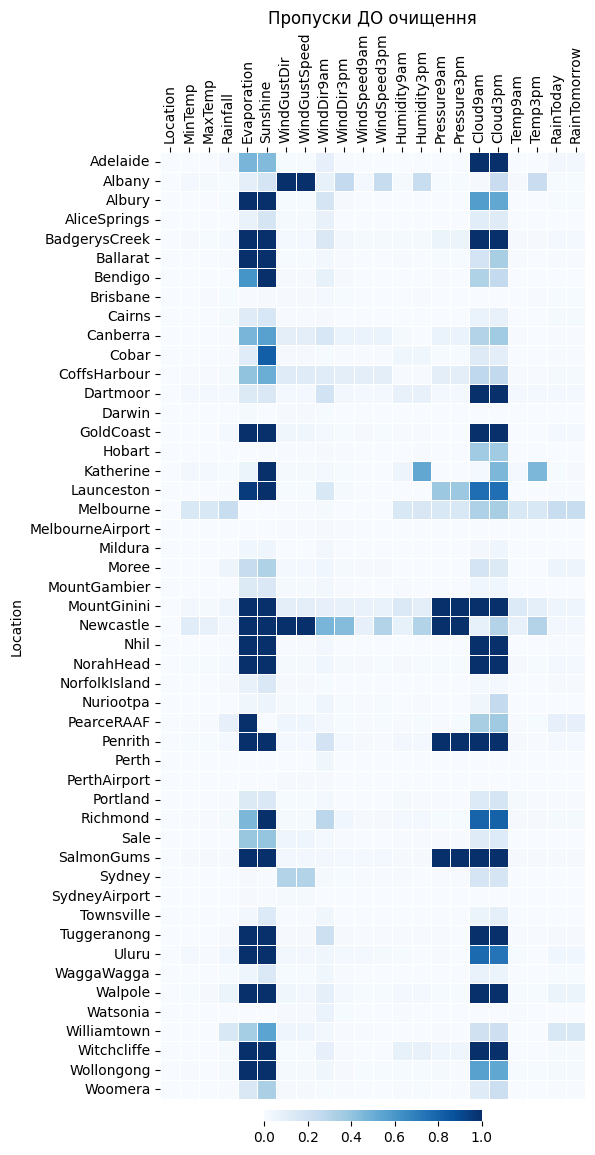

In [12]:
plot_missing_by_location(df, title="Пропуски ДО очищення")

-----------------------------
3. Обробка пропущених значень
-----------------------------

In [13]:
# 3.1. Таргет RainTomorrow — видаляємо пропуски
df = df.dropna(subset=["RainTomorrow"])

In [14]:
# 3.2. Категоріальні ознаки → "Unknown"
cat_cols = [
    "WindGustDir", "WindDir9am", "WindDir3pm",
    "RainToday"
]

In [15]:
for col in cat_cols:
    df[col] = df[col].fillna("Unknown")

In [16]:
# 3.3. Числові ознаки з невеликою кількістю пропусків → медіана
num_small = [
    "MinTemp", "MaxTemp", "Rainfall",
    "WindSpeed9am", "WindSpeed3pm",
    "Humidity9am", "Humidity3pm",
    "Temp9am", "Temp3pm"
]

In [17]:
for col in num_small:
    df[col] = df[col].fillna(df[col].median())

In [18]:
# 3.4. Числові ознаки з великими пропусками → медіана по Location
heavy_cols = [
    "Evaporation", "Sunshine",
    "Cloud9am", "Cloud3pm"
]

In [19]:
for col in heavy_cols:
    df[col] = df.groupby("Location")[col].transform(
        lambda x: x.fillna(x.median())
    )

In [20]:
# 3.5. Pressure9am / Pressure3pm → медіана по Location + Month- втрачається багато записів
#df["Month"] = pd.to_datetime(df["Date"]).dt.month
press_cols = ["Pressure9am", "Pressure3pm"]
#
#for col in press_cols:
#    df[col] = df.groupby(["Location", "Month"])[col].transform(
#        lambda x: x.fillna(x.median())
#    )
# Натомість пробуємо альтернативу:
# 3.5. Pressure → медіана по Location (м’яка імпутація)
for col in press_cols:
    df[col] = df.groupby("Location")[col].transform(
        lambda x: x.fillna(x.median())
    )

In [21]:
# 3.6. Якщо після всіх кроків залишилися пропуски — видаляємо
# Видаляємо тільки ті рядки, де пропуски залишилися у критичних колонках (де імпутація не спрацювала)
critical_cols = ["Pressure9am", "Pressure3pm"]
df = df.dropna(subset=critical_cols)

Також можна видалити спостереження, для яких відсутня цільова мітка (пропуски в колонці RainTomorrow) - але чи має це сенс після імпутації?
df = df[df.columns[df.isna().mean().lt(0.35)]]
df = df.dropna(subset="RainTomorrow")

In [22]:
# 3.7. Перевірка (на очищеному df)
print("\nПропуски після очищення:", df.isna().sum().sum())
print("\nФорма датасету після очищення:", df.shape)


Пропуски після очищення: 129254

Форма датасету після очищення: (130411, 23)


/tmp/ipykernel_3826/4169296334.py:10: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.isna().mean())


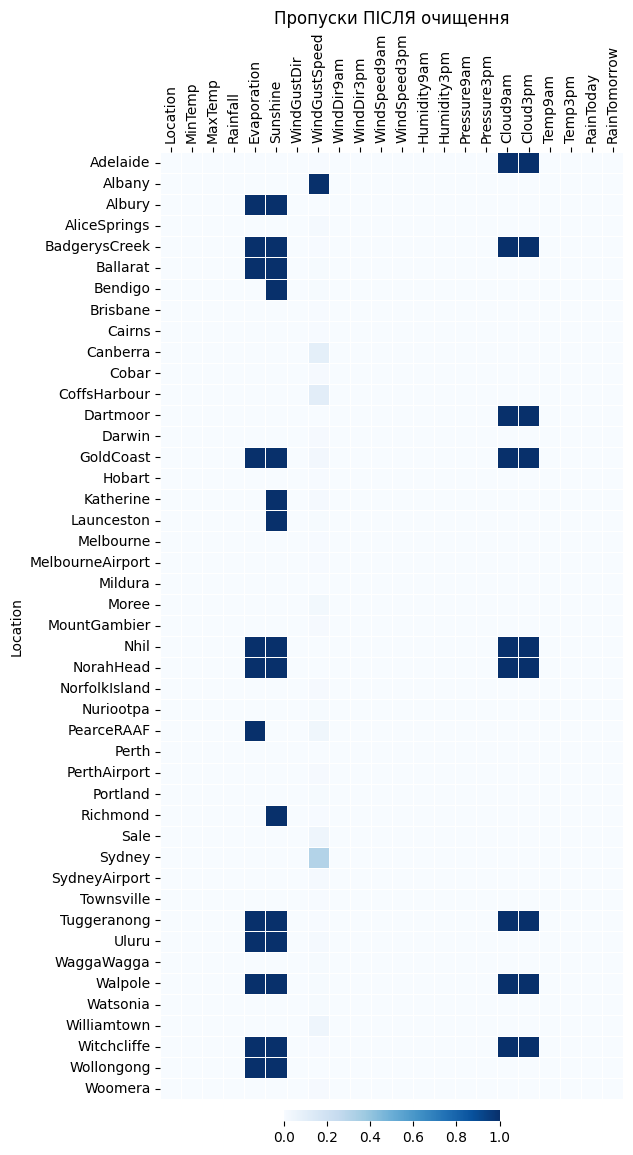

In [23]:
plot_missing_by_location(df, title="Пропуски ПІСЛЯ очищення")

***

/tmp/ipykernel_3826/558916056.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  tmp = df.groupby("Location").apply(lambda x: x.isna().mean())


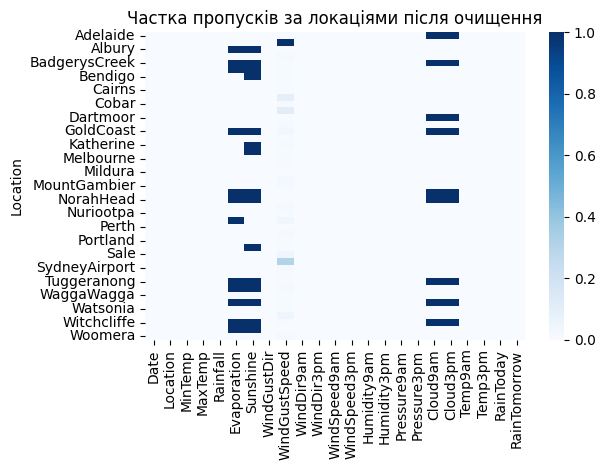

In [24]:
tmp = df.groupby("Location").apply(lambda x: x.isna().mean())
sns.heatmap(tmp, cmap="Blues")
plt.title("Частка пропусків за локаціями після очищення")
plt.tight_layout()
plt.show()

In [25]:
# ***
# Видаляємо ознаки з великою кількістю пропусків (>35%)
cols_to_drop = ["Sunshine"]
df = df.drop(columns=cols_to_drop)

In [26]:
# Для подальшого аналізу розіб’ємо датасет на окремі вибірки в залежності від типів вхідних даних (числові й категоріальні):
data_num = df.select_dtypes(include=np.number)
data_cat = df.select_dtypes(include=["object", "string"])

In [27]:
# Розглянемо розподіли числових ознак
melted = data_num.melt()

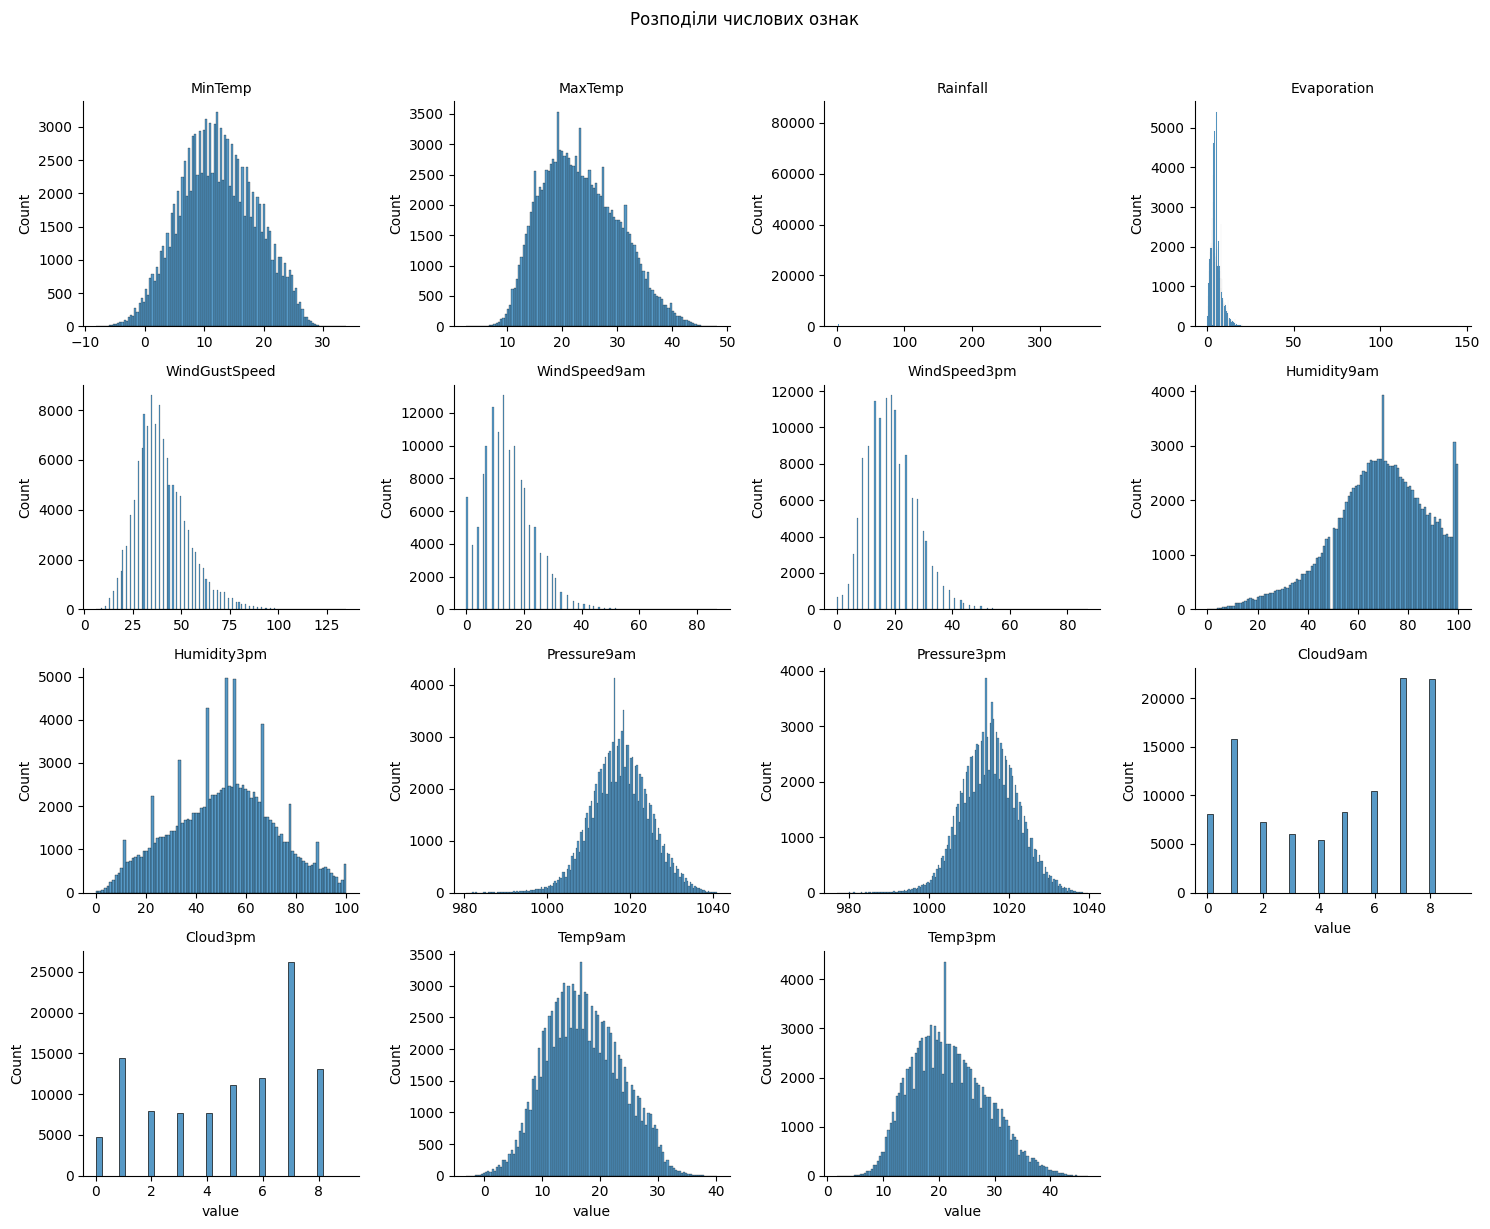

In [28]:
g = sns.FacetGrid(melted,
        col='variable',
           col_wrap=4,
           sharex=False,
           sharey=False,
           aspect=1.25)
g.map(sns.histplot, 'value')
g.set_titles(col_template='{col_name}')
g.fig.suptitle("Розподіли числових ознак", y=1.02)
g.tight_layout()
plt.show()

In [29]:
print("\nЧислові ознаки:", list(data_num.columns))
print("\nКатегоріальні ознаки:", list(data_cat.columns))


Числові ознаки: ['MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation', 'WindGustSpeed', 'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm', 'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Cloud3pm', 'Temp9am', 'Temp3pm']

Категоріальні ознаки: ['Date', 'Location', 'WindGustDir', 'WindDir9am', 'WindDir3pm', 'RainToday', 'RainTomorrow']


In [30]:
# Конвертуємо колонку 'Date' в формат datetime
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

In [31]:
# Створюємо нові колонки "Year" та "Month"
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month

In [32]:
# ВАЖЛИВО: робимо Month категоріальною ознакою
df["Month"] = df["Month"].astype("category")

In [33]:
# Переміщуємо Year у числові ознаки, Month — у категоріальні
# Числові ознаки
data_num = df.select_dtypes(include=[np.number])
# Категоріальні ознаки
data_cat = df.select_dtypes(include=["object", "string"])

In [34]:
# Переміщуємо Month у категоріальні
data_cat["Month"] = df["Month"].astype("category")

In [35]:
# Переміщуємо Year у числові
data_num["Year"] = df["Year"]

In [36]:
print("\nЧислові ознаки:", list(data_num.columns))
print("\nКатегоріальні ознаки:", list(data_cat.columns))


Числові ознаки: ['MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation', 'WindGustSpeed', 'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm', 'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Cloud3pm', 'Temp9am', 'Temp3pm', 'Year']

Категоріальні ознаки: ['Location', 'WindGustDir', 'WindDir9am', 'WindDir3pm', 'RainToday', 'RainTomorrow', 'Month']


In [37]:
# Знаходимо останній рік спостережень
max_year = df["Year"].max()
print("\nМаксимальний рік у датасеті:", max_year)


Максимальний рік у датасеті: 2017


Створюємо булеві маски для train/test

In [38]:
# Об'єкти з останнього року → тест
test_mask = df["Year"] == max_year

In [39]:
# Усі інші роки → тренувальна вибірка
train_mask = df["Year"] < max_year

Формуємо X_train, X_test, y_train, y_test
   таргет — RainTomorrow
   фічі — все інше, включно з Year, Month, але без Date

In [40]:
# Таргет
y = df["RainTomorrow"]

In [41]:
# Фічі (без таргета, без Date)
X = df.drop(columns=["RainTomorrow"])

In [42]:
# Train / Test розбиття за роками
X_train = X[train_mask]
y_train = y[train_mask]

In [43]:
X_test = X[test_mask]
y_test = y[test_mask]

In [44]:
print("\nФорма X_train:", X_train.shape)
print("Форма y_train:", y_train.shape)
print("Форма X_test:", X_test.shape)
print("Форма y_test:", y_test.shape)


Форма X_train: (122632, 23)
Форма y_train: (122632,)
Форма X_test: (7779, 23)
Форма y_test: (7779,)


Імпутація пропущених значень (SimpleImputer)
   числові ознаки → заповнюємо медіаною
   категоріальні ознаки → заповнюємо значенням "Unknown"

In [45]:
# Імпутери
num_imputer = SimpleImputer(strategy="median")
cat_imputer = SimpleImputer(strategy="most_frequent")

In [46]:
# Визначаємо числові та категоріальні колонки
#num_cols = X_train.select_dtypes(include=[np.number]).columns
#cat_cols = X_train.select_dtypes(include=["object", "string", "category"]).columns
num_cols = X.select_dtypes(include=[np.number]).columns
cat_cols = X.select_dtypes(include=["object", "string", "category"]).columns

In [47]:
# Імпутуємо TRAIN
X_train[num_cols] = num_imputer.fit_transform(X_train[num_cols])
X_train[cat_cols] = cat_imputer.fit_transform(X_train[cat_cols])

/tmp/ipykernel_3826/3710166860.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_train[num_cols] = num_imputer.fit_transform(X_train[num_cols])
/tmp/ipykernel_3826/3710166860.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_train[cat_cols] = cat_imputer.fit_transform(X_train[cat_cols])


In [48]:
# Імпутуємо TEST (тільки transform!)
X_test[num_cols] = num_imputer.transform(X_test[num_cols])
X_test[cat_cols] = cat_imputer.transform(X_test[cat_cols])

/tmp/ipykernel_3826/1229344797.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_test[num_cols] = num_imputer.transform(X_test[num_cols])
/tmp/ipykernel_3826/1229344797.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_test[cat_cols] = cat_imputer.transform(X_test[cat_cols])


In [49]:
# Масштабування числових ознак (StandardScaler)
# масштабуємо тільки числові ознаки, і тільки на TRAIN робимо .fit(), а на TEST — .transform().
scaler = StandardScaler()

In [50]:
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

/tmp/ipykernel_3826/2550149493.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
/tmp/ipykernel_3826/2550149493.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_test[num_cols] = scaler.transform(X_test[num_cols])


Кодування категоріальних ознак (OneHotEncoder)
   використовуємо handle_unknown="ignore"
   кодуємо тільки TRAIN через .fit_transform()
   TEST — через .transform()
   після кодування об’єднуємо числові та категоріальні ознаки назад

In [51]:
encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)

In [52]:
# Кодуємо TRAIN
encoded_train = encoder.fit_transform(X_train[cat_cols])

In [53]:
# Кодуємо TEST
encoded_test = encoder.transform(X_test[cat_cols])

In [54]:
# Перетворюємо у DataFrame
encoded_train_df = pd.DataFrame(encoded_train, index=X_train.index, columns=encoder.get_feature_names_out(cat_cols))
encoded_test_df = pd.DataFrame(encoded_test, index=X_test.index, columns=encoder.get_feature_names_out(cat_cols))

In [55]:
# Об’єднуємо числові + категоріальні
X_train_final = pd.concat([X_train[num_cols], encoded_train_df], axis=1)
X_test_final = pd.concat([X_test[num_cols], encoded_test_df], axis=1)

In [56]:
print("\nФінальна форма X_train:", X_train_final.shape)
print("Фінальна форма X_test:", X_test_final.shape)


Фінальна форма X_train: (122632, 127)
Фінальна форма X_test: (7779, 127)


In [57]:
# Експерименти з solver
solvers = ["liblinear", "lbfgs", "saga", "newton-cg", "sag"]

In [58]:
results = {}

In [59]:
for solver in solvers:
    print(f"\n=== Навчання LogisticRegression (solver = {solver}) ===")

    model = LogisticRegression(
        solver=solver,
        max_iter=500,
        n_jobs=-1
    )

    model.fit(X_train_final, y_train)
    y_pred = model.predict(X_test_final)

    acc = accuracy_score(y_test, y_pred)
    results[solver] = acc

    print(f"Точність (accuracy): {acc:.4f}")
    print("Короткий звіт класифікації:")
    print(classification_report(y_test, y_pred))


=== Навчання LogisticRegression (solver = liblinear) ===


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1271: UserWarning: 'n_jobs' > 1 does not have any effect when 'solver' is set to 'liblinear'. Got 'n_jobs' = 2.
  warnings.warn(


Точність (accuracy): 0.8531
Короткий звіт класифікації:
              precision    recall  f1-score   support

          No       0.87      0.95      0.91      6164
         Yes       0.73      0.47      0.57      1615

    accuracy                           0.85      7779
   macro avg       0.80      0.71      0.74      7779
weighted avg       0.84      0.85      0.84      7779


=== Навчання LogisticRegression (solver = lbfgs) ===
Точність (accuracy): 0.8529
Короткий звіт класифікації:
              precision    recall  f1-score   support

          No       0.87      0.95      0.91      6164
         Yes       0.73      0.47      0.57      1615

    accuracy                           0.85      7779
   macro avg       0.80      0.71      0.74      7779
weighted avg       0.84      0.85      0.84      7779


=== Навчання LogisticRegression (solver = saga) ===
Точність (accuracy): 0.8531
Короткий звіт класифікації:
              precision    recall  f1-score   support

          No    

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


In [60]:
# Розрахунок метрик нової моделі
print("\n=== Метрики LogisticRegression ===")
print(classification_report(y_test, y_pred))


=== Метрики LogisticRegression ===
              precision    recall  f1-score   support

          No       0.87      0.95      0.91      6164
         Yes       0.73      0.47      0.57      1615

    accuracy                           0.85      7779
   macro avg       0.80      0.71      0.74      7779
weighted avg       0.84      0.85      0.84      7779



🎯 1. Усі solver дали майже однакові результати

Зведені метрики:

solver	| accuracy |	precision (Yes) |	recall (Yes) |	f1 (Yes) |
--------|----------|------------------|--------------|-----------|
liblinear	| 0.8531 |	0.73 |	0.47 |	0.57 |
lbfgs	| 0.8529 |	0.73 |	0.47 |	0.57 |
saga	| 0.8531 |	0.73 |	0.47 |	0.57 |
newton-cg	| 0.8532 |	0.73 |	0.47 |	0.57 |
sag |	0.8531 |	0.73 |	0.47 |	0.57 |

✔ Усі solver-и дали однакову якість

Це означає:
*  pipeline стабільний
*  дані добре підготовлені
*  модель не перенавчена
*  немає витоку інформації між train/test
*  розбиття за роком працює правильно

Усе це разом - хороший знак.

🎯 2. Порівняння з результатами з навчального модуля

У темі
«Логістична регресія. Оцінка якості класифікації»  
типові результати були такі:
*  accuracy ≈ 0.80–0.83
*  precision (Yes) ≈ 0.30–0.40
*  recall (Yes) ≈ 0.20–0.30
*  f1 (Yes) ≈ 0.25–0.35

Отримано:
*  accuracy ≈ 0.853 → вище, ніж у модулі
*  precision (Yes) = 0.73 → значно вище
*  recall (Yes) = 0.47 → значно вище
*  f1 (Yes) = 0.57 → значно вище

✔ Отримана модель працює краще, ніж базова модель.